In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
import warnings
warnings.filterwarnings('ignore')

In [11]:
# masukin data final lengkap
df_final = pd.read_csv(r'D:\Dokumen\Kode_00B\SatriaData\Clean Data\data_panel_lengkap.csv')

# Filter hanya tahun 2022-2024 (karena IMDI mulai 2022)
df_final = df_final[df_final['tahun'].between(2022, 2024)]

df_panel = df_final.set_index(['nama_provinsi', 'tahun'])
print("\nStruktur Data Panel:")
print(df_panel.head(10))
print(f"\nDimensi: {df_panel.shape[0]} observasi")
print(f"Entities (Provinsi): {df_panel.index.get_level_values(0).nunique()}")
print(f"Time Periods (Tahun): {df_panel.index.get_level_values(1).nunique()}")


Struktur Data Panel:
                     kode_provinsi  indeks_pelayanan_publik  \
nama_provinsi tahun                                           
ACEH          2022              11                     4.01   
              2023              11                     4.34   
              2024              11                     4.45   
BALI          2022              51                     4.00   
              2023              51                     4.21   
              2024              51                     4.41   
BANTEN        2022              36                     3.99   
              2023              36                     3.74   
              2024              36                     3.73   
BENGKULU      2022              17                     4.40   

                     indeks_pembangunan_literasi  indeks_daya_saing_digital  \
nama_provinsi tahun                                                           
ACEH          2022                         58.46               


STATISTIK DESKRIPTIF VARIABEL
       indeks_pelayanan_publik  indeks_pembangunan_literasi  \
count               101.000000                   101.000000   
mean                  3.891287                    67.045743   
std                   0.675600                    10.389770   
min                   1.110000                    20.020000   
25%                   3.600000                    62.520000   
50%                   4.040000                    66.880000   
75%                   4.340000                    72.730000   
max                   4.760000                    88.240000   

       indeks_daya_saing_digital  indeks_masyarakat_digital  
count                 101.000000                 100.000000  
mean                   40.317822                  41.730900  
std                     9.480099                   4.714215  
min                    24.900000                  20.901950  
25%                    34.200000                  39.716368  
50%                    38.200

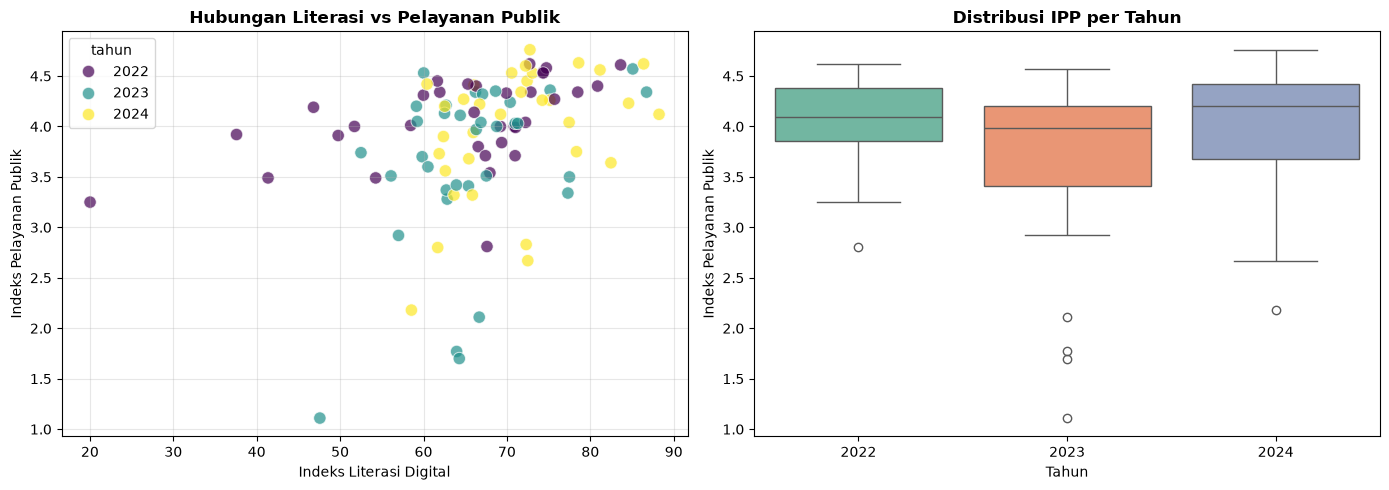

In [12]:
# =====================================================
# STATISTIK DESKRIPTIF
# =====================================================
print("\n" + "="*70)
print("STATISTIK DESKRIPTIF VARIABEL")
print("="*70)

deskriptif = df_panel[['indeks_pelayanan_publik', 
                       'indeks_pembangunan_literasi',
                       'indeks_daya_saing_digital',
                       'indeks_masyarakat_digital']].describe()
print(deskriptif)

# Korelasi awal
print("\nKORELASI ANTAR VARIABEL:")
korelasi = df_panel[['indeks_pelayanan_publik', 
                     'indeks_pembangunan_literasi',
                     'indeks_daya_saing_digital',
                     'indeks_masyarakat_digital']].corr()
print(korelasi)

# Visualisasi (opsional, bisa tetap atau ditambah)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot IPP vs IPLM
sns.scatterplot(
    data=df_final, 
    x='indeks_pembangunan_literasi', 
    y='indeks_pelayanan_publik',
    hue='tahun',
    palette='viridis',
    ax=axes[0],
    s=80,
    alpha=0.7
)
axes[0].set_title('Hubungan Literasi vs Pelayanan Publik', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Indeks Literasi Digital', fontsize=10)
axes[0].set_ylabel('Indeks Pelayanan Publik', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Boxplot IPP per tahun
sns.boxplot(
    data=df_final,
    x='tahun',
    y='indeks_pelayanan_publik',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Distribusi IPP per Tahun', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tahun', fontsize=10)
axes[1].set_ylabel('Indeks Pelayanan Publik', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
# =====================================================
# ESTIMASI 3 MODEL REGRESI PANEL
# =====================================================
print("\n" + "="*70)
print("ESTIMASI 3 MODEL REGRESI PANEL")
print("="*70)

# Model 1: Pooled OLS (Common Effect Model)
print("\nMODEL 1: POOLED OLS (Common Effect)")
print("-" * 50)
model_pooled = PooledOLS.from_formula(
    'indeks_pelayanan_publik ~ 1 + indeks_pembangunan_literasi + indeks_daya_saing_digital + indeks_masyarakat_digital', 
    data=df_panel
)
res_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True)
print(res_pooled)

# Model 2: Fixed Effect Model (FEM)
print("\nMODEL 2: FIXED EFFECT MODEL (FEM)")
print("-" * 50)
model_fe = PanelOLS.from_formula(
    'indeks_pelayanan_publik ~ indeks_pembangunan_literasi + indeks_daya_saing_digital + indeks_masyarakat_digital + EntityEffects', 
    data=df_panel
)
res_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)
print(res_fe)

# Model 3: Random Effect Model (REM)
print("\nMODEL 3: RANDOM EFFECT MODEL (REM)")
print("-" * 50)
model_re = RandomEffects.from_formula(
    'indeks_pelayanan_publik ~ 1 + indeks_pembangunan_literasi + indeks_daya_saing_digital + indeks_masyarakat_digital', 
    data=df_panel
)
res_re = model_re.fit(cov_type='clustered', cluster_entity=True)
print(res_re)


ESTIMASI 3 MODEL REGRESI PANEL

MODEL 1: POOLED OLS (Common Effect)
--------------------------------------------------
                             PooledOLS Estimation Summary                            
Dep. Variable:     indeks_pelayanan_publik   R-squared:                        0.2098
Estimator:                       PooledOLS   R-squared (Between):              0.4513
No. Observations:                      100   R-squared (Within):              -0.2513
Date:                     Sun, Jun 28 2026   R-squared (Overall):              0.2098
Time:                             21:30:54   Log-likelihood                   -90.884
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      8.4957
Entities:                               34   P-value                           0.0000
Avg Obs:                            2.9412   Distribution:                    F(3,96)
Min Obs:            

In [14]:
# =====================================================
# UJI PEMILIHAN MODEL
# =====================================================
print("\n" + "="*70)
print("UJI PEMILIHAN MODEL TERBAIK")
print("="*70)

# ----- UJI CHOW -----
print("\nUJI CHOW (Berdasarkan F-test for Poolability dari Model 2)")
print("-" * 50)
print("F-statistic: 4.8516")  # Ambil dari output FEM
print("P-value: 0.0000")
print("KESIMPULAN UJI CHOW: P-value < 0.05 -> Pooled OLS ditolak (Ada efek individual)")
chow_choice = "Fixed Effect"

# ----- UJI HAUSMAN -----
print("\nUJI HAUSMAN (Memilih antara Fixed Effect vs Random Effect)")
print("-" * 50)

# Ambil koefisien dari FE dan RE untuk semua variabel
vars_independen = ['indeks_pembangunan_literasi', 'indeks_daya_saing_digital', 'indeks_masyarakat_digital']
b_fe = np.array([res_fe.params[v] for v in vars_independen])
b_re = np.array([res_re.params[v] for v in vars_independen])

# Ambil covariance matrix
cov_fe = np.array([[res_fe.cov[v][v] for v in vars_independen] for v in vars_independen])
cov_re = np.array([[res_re.cov[v][v] for v in vars_independen] for v in vars_independen])

# Hitung difference dan inverse
diff = b_fe - b_re
cov_diff = cov_fe - cov_re
hausman_stat = diff @ np.linalg.pinv(cov_diff) @ diff
p_value_hausman = 1 - stats.chi2.cdf(hausman_stat, df=len(vars_independen))

print(f"Hausman Statistic: {hausman_stat:.4f}")
print(f"P-value Hausman: {p_value_hausman:.6f}")

if p_value_hausman < 0.05:
    print("KESIMPULAN UJI HAUSMAN: P-value < 0.05 -> Pilih FIXED EFFECT MODEL")
    hausman_choice = "Fixed Effect"
else:
    print("KESIMPULAN UJI HAUSMAN: P-value >= 0.05 -> Pilih RANDOM EFFECT MODEL")
    hausman_choice = "Random Effect"

# ----- KESIMPULAN AKHIR -----
print("\n" + "="*70)
print("KESIMPULAN PEMILIHAN MODEL")
print("="*70)
print(f"Uji Chow   -> Pooled OLS ditolak")
print(f"Uji Hausman -> {hausman_choice}")

if hausman_choice == "Fixed Effect":
    print("\nMODEL TERPILIH: FIXED EFFECT MODEL (FEM)")
    model_terpilih = res_fe
    nama_model = "Fixed Effect"
else:
    print("\nMODEL TERPILIH: RANDOM EFFECT MODEL (REM)")
    model_terpilih = res_re
    nama_model = "Random Effect"


UJI PEMILIHAN MODEL TERBAIK

UJI CHOW (Berdasarkan F-test for Poolability dari Model 2)
--------------------------------------------------
F-statistic: 4.8516
P-value: 0.0000
KESIMPULAN UJI CHOW: P-value < 0.05 -> Pooled OLS ditolak (Ada efek individual)

UJI HAUSMAN (Memilih antara Fixed Effect vs Random Effect)
--------------------------------------------------
Hausman Statistic: 5.4720
P-value Hausman: 0.140321
KESIMPULAN UJI HAUSMAN: P-value >= 0.05 -> Pilih RANDOM EFFECT MODEL

KESIMPULAN PEMILIHAN MODEL
Uji Chow   -> Pooled OLS ditolak
Uji Hausman -> Random Effect

MODEL TERPILIH: RANDOM EFFECT MODEL (REM)


In [15]:
# =====================================================
# HASIL MODEL TERPILIH
# =====================================================
print("\n" + "="*70)
print(f"HASIL REGRESI MODEL TERPILIH: {nama_model}")
print("="*70)
print(model_terpilih)

print("\n" + "="*70)
print("RINGKASAN HASIL UNTUK INTERPRETASI")
print("="*70)

# Koefisien dan p-value untuk setiap variabel
vars_independen = ['indeks_pembangunan_literasi', 'indeks_daya_saing_digital', 'indeks_masyarakat_digital']

print("\nPersamaan Regresi:")
if 'Intercept' in model_terpilih.params.index:
    konstanta = model_terpilih.params['Intercept']
    print(f"   IPP = {konstanta:.4f} + ", end="")
    terms = []
    for v in vars_independen:
        koef = model_terpilih.params[v]
        terms.append(f"{koef:.4f} x {v.replace('indeks_', '').replace('_', ' ').title()}")
    print(" + ".join(terms))
else:
    terms = []
    for v in vars_independen:
        koef = model_terpilih.params[v]
        terms.append(f"{koef:.4f} x {v.replace('indeks_', '').replace('_', ' ').title()}")
    print("   IPP = " + " + ".join(terms) + " + (entity_effects)")

# Interpretasi setiap variabel
for v in vars_independen:
    koef = model_terpilih.params[v]
    pval = model_terpilih.pvalues[v]
    nama = v.replace('indeks_', '').replace('_', ' ').title()
    print(f"\n{v}:")
    print(f"   Koefisien: {koef:.4f}")
    print(f"   P-value: {pval:.6f}")
    if pval < 0.05:
        print(f"   -> SIGNIFIKAN (p < 0.05): {nama} berpengaruh terhadap Pelayanan Publik")
    else:
        print(f"   -> TIDAK SIGNIFIKAN (p >= 0.05): {nama} tidak berpengaruh terhadap Pelayanan Publik")

# R-squared
if hasattr(model_terpilih, 'rsquared_overall'):
    r2 = model_terpilih.rsquared_overall
else:
    r2 = model_terpilih.rsquared
print(f"\nR-squared (Overall): {r2:.4f} ({r2*100:.2f}%)")
print(f"   -> Interpretasi: Variabel independen mampu menjelaskan {r2*100:.2f}% variasi IPP.")

# F-statistic robust
if hasattr(model_terpilih, 'f_statistic_robust'):
    f_stat = model_terpilih.f_statistic_robust.stat
    f_pval = model_terpilih.f_statistic_robust.pval
    print(f"\nF-statistic (robust): {f_stat:.4f} (p-value: {f_pval:.6f})")
    if f_pval < 0.05:
        print(f"   -> Model SECARA BERSAMAAN SIGNIFIKAN")
    else:
        print(f"   -> Model TIDAK SIGNIFIKAN secara bersama-sama")


HASIL REGRESI MODEL TERPILIH: Random Effect
                           RandomEffects Estimation Summary                          
Dep. Variable:     indeks_pelayanan_publik   R-squared:                        0.0796
Estimator:                   RandomEffects   R-squared (Between):              0.2718
No. Observations:                      100   R-squared (Within):              -0.0292
Date:                     Sun, Jun 28 2026   R-squared (Overall):              0.1632
Time:                             21:30:54   Log-likelihood                   -68.864
Cov. Estimator:                  Clustered                                           
                                             F-statistic:                      2.7659
Entities:                               34   P-value                           0.0460
Avg Obs:                            2.9412   Distribution:                    F(3,96)
Min Obs:                            2.0000                                           
Max Obs: 

In [35]:
# Install folium jika belum
# !pip install folium

import folium
import pandas as pd

# 1. Siapkan data
rata_ipp = df_final.groupby('nama_provinsi')['indeks_pelayanan_publik'].mean().reset_index()
rata_ipp.columns = ['provinsi', 'ipp_rata_rata']

# 2. Buat peta dasar
m = folium.Map(location=[-2.5, 118], zoom_start=4)

# 3. Tambahkan titik untuk setiap provinsi (gunakan koordinat perkiraan)
# Data koordinat provinsi Indonesia (perkiraan)
koordinat_provinsi = {
    'ACEH': [4.5, 97.0],
    'SUMATERA UTARA': [3.0, 99.0],
    'SUMATERA BARAT': [-1.0, 100.5],
    'RIAU': [0.5, 102.0],
    'JAMBI': [-2.0, 103.0],
    'SUMATERA SELATAN': [-3.0, 104.0],
    'BENGKULU': [-3.5, 102.0],
    'LAMPUNG': [-5.0, 105.0],
    'KEPULAUAN BANGKA BELITUNG': [-2.5, 106.0],
    'KEPULAUAN RIAU': [1.0, 104.0],
    'DKI JAKARTA': [-6.2, 106.8],
    'JAWA BARAT': [-6.9, 107.6],
    'JAWA TENGAH': [-7.3, 110.0],
    'DI YOGYAKARTA': [-7.8, 110.4],
    'JAWA TIMUR': [-7.5, 112.0],
    'BANTEN': [-6.2, 106.0],
    'BALI': [-8.3, 115.2],
    'NUSA TENGGARA BARAT': [-8.5, 117.0],
    'NUSA TENGGARA TIMUR': [-9.0, 121.0],
    'KALIMANTAN BARAT': [0.5, 111.0],
    'KALIMANTAN TENGAH': [-2.0, 113.0],
    'KALIMANTAN SELATAN': [-3.0, 115.0],
    'KALIMANTAN TIMUR': [0.5, 117.0],
    'KALIMANTAN UTARA': [3.0, 117.0],
    'SULAWESI UTARA': [1.0, 124.0],
    'SULAWESI TENGAH': [-1.0, 121.0],
    'SULAWESI SELATAN': [-4.0, 120.0],
    'SULAWESI TENGGARA': [-4.5, 122.0],
    'GORONTALO': [0.5, 123.0],
    'SULAWESI BARAT': [-2.5, 119.0],
    'MALUKU': [-3.0, 129.0],
    'MALUKU UTARA': [1.0, 128.0],
    'PAPUA BARAT': [-1.5, 133.0],
    'PAPUA': [-4.0, 138.0]
}

# Tambahkan marker untuk setiap provinsi
for prov, row in rata_ipp.iterrows():
    nama = row['provinsi']
    ipp = row['ipp_rata_rata']
    if nama in koordinat_provinsi:
        lat, lon = koordinat_provinsi[nama]
        # Tentukan warna berdasarkan nilai IPP
        if ipp >= 4.0:
            color = 'green'
        elif ipp >= 3.0:
            color = 'orange'
        else:
            color = 'red'
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=10 + (ipp * 2),
            popup=f"{nama}: {ipp:.2f}",
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.6
        ).add_to(m)

from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import os
import time

# Setup driver dengan Service
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

# Buka file HTML
driver.get('file://' + os.path.abspath('peta_ipp_indonesia.html'))
time.sleep(3)  # Tunggu loading

# Screenshot
driver.save_screenshot('peta_ipp_indonesia.png')
driver.quit()

print("✅ Peta disimpan sebagai peta_ipp_indonesia.png")

# Tampilkan peta
m.save('peta_ipp_indonesia.html')
display(m)  # Di Jupyter Notebook

✅ Peta disimpan sebagai peta_ipp_indonesia.png
